# Testing the creating of BMGs using Asymmetree

In [21]:
import asymmetree.treeevolve as te
from asymmetree.utils.phylogenetic_trees import to_newick
from asymmetree.visualization.tree_vis import visualize, assign_colors
import asymmetree.analysis.best_matches as bm
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Species Tree (example from Asymmetree docs)

In [4]:
S = te.species_tree_n_age(
    10, 1.0, contraction_probability=0.0, contraction_proportion=0.2, contraction_bias="exponential"
)
print(to_newick(S))

------------- S -------------
((((8:0.42659442059702124,9:0.42659442059702124)5:0.23107098235911472,(16:0.24340499359031156,17:0.24340499359031156)10:0.4142604093658244,(((18:0.07253966952010761,19:0.07253966952010761)15:0.20237831756948482,14:0.2749179870895924)12:0.07528488626374186,13:0.3502028733533343)11:0.3074625296028017)2:0.17001930468812887,7:0.8276847076442648,6:0.8276847076442648)1:0.17231529235573517)0:0.0;


Gene Tree

In [40]:
T = te.dated_gene_tree(
    S, dupl_rate=1.0, loss_rate=0, hgt_rate=0.2, gc_rate=0.2, prohibit_extinction="per_species"
)

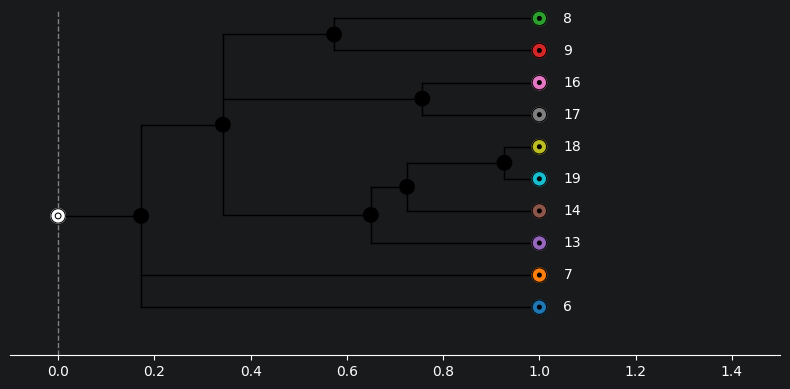

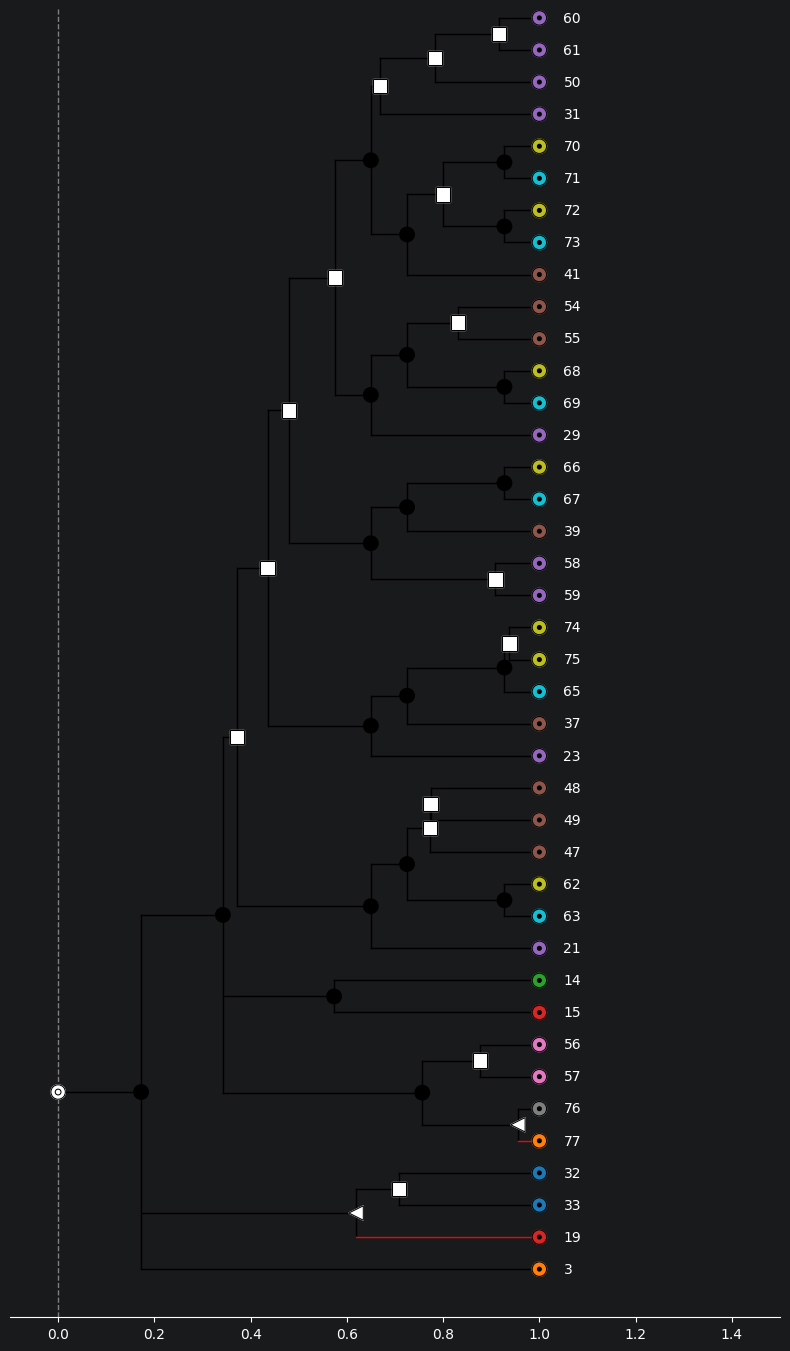

In [41]:
species_colors, gene_colors = assign_colors(S, T)

visualize(S, color_dict=species_colors) #, save_as="testfile_speciestree.pdf")
visualize(T, color_dict=gene_colors) #, save_as="testfile_genetree.pdf")

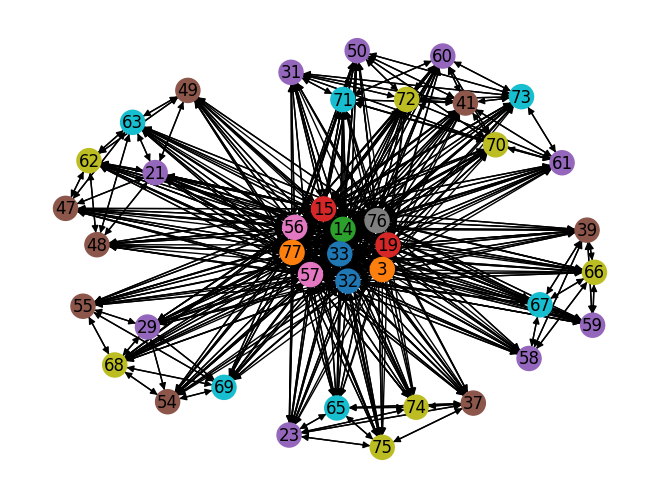

In [43]:
#OGT = te.prune_losses(T)
bmg = bm.bmg_from_tree(T) # (OGT)
nx.draw(bmg,with_labels=True, node_color=[x for x in gene_colors.values()])
#ign_colors(S, T)

#visualize(bmg, color_dict=species_colors)

In [50]:
candidates = {n for n in nx.descendants(bmg, 65) if n in set([23,75,74,65,67,59,66,73])}
candidates

{23, 59, 66, 67, 73, 74, 75}

{'b1', 'c1'}

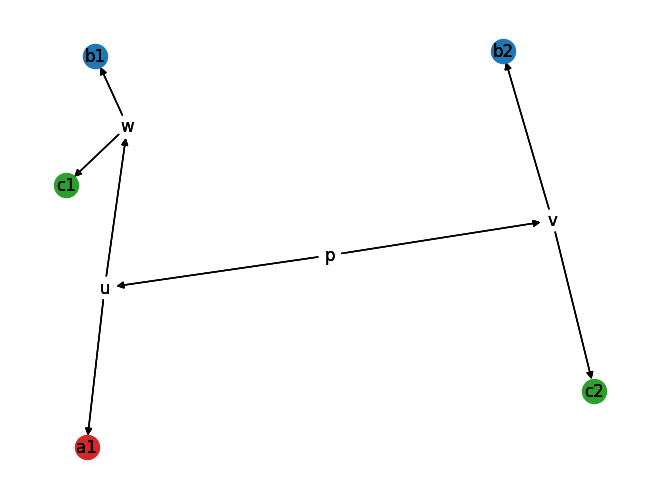

In [57]:
# Exercise 4
diG_root = nx.DiGraph()
diG_root.add_node("a1", color='red')
diG_root.add_node("b1", color='blue')
diG_root.add_node("b2", color='blue')
diG_root.add_node("c1", color='green')
diG_root.add_node("c2", color='green')
nx.add_path(diG_root, ["p","u","w"])
nx.add_path(diG_root, ["p","v"])
diG_root.add_edge("u", "a1")
diG_root.add_edge("w", "b1")
diG_root.add_edge("w", "c1")
diG_root.add_edge("v", "b2")
diG_root.add_edge("v", "c2")
#nx.add_path(diG, ["p","u","a1"])
#nx.add_path(diG, ["p","u","w","b1"])
#nx.add_path(diG, ["p","u","w","c1"])
#nx.add_path(diG, ["p","v","b2"])
#nx.add_path(diG, ["p","v","c2"])

pos = nx.spring_layout(diG_root)
nx.draw(diG_root, pos, nodelist=["a1"], node_color="tab:red", with_labels=True)
nx.draw(diG_root, pos, nodelist=["b1", "b2"], node_color="tab:blue", with_labels=True)
nx.draw(diG_root, pos, nodelist=["c1", "c2"], node_color="tab:green", with_labels=True)
candidates = {n for n in nx.descendants(diG_root, "u") if n in set(["a1","b1","b2","c1","c2"])}
candidates -= {"a1"}
candidates

In [26]:
print(gene_colors)
#print(gene_colors.values())
[x for x in gene_colors.values()]

{39: array([0.49803922, 0.49803922, 0.49803922, 1.        ]), 47: array([0.12156863, 0.46666667, 0.70588235, 1.        ]), 41: array([0.12156863, 0.46666667, 0.70588235, 1.        ]), 36: array([0.89019608, 0.46666667, 0.76078431, 1.        ]), 37: array([0.49803922, 0.49803922, 0.49803922, 1.        ]), 58: array([0.7372549 , 0.74117647, 0.13333333, 1.        ]), 59: array([0.54901961, 0.3372549 , 0.29411765, 1.        ]), 55: array([0.09019608, 0.74509804, 0.81176471, 1.        ]), 31: array([0.54901961, 0.3372549 , 0.29411765, 1.        ]), 23: array([0.58039216, 0.40392157, 0.74117647, 1.        ]), 56: array([0.58039216, 0.40392157, 0.74117647, 1.        ]), 57: array([0.58039216, 0.40392157, 0.74117647, 1.        ]), 35: array([0.58039216, 0.40392157, 0.74117647, 1.        ]), 27: array([0.58039216, 0.40392157, 0.74117647, 1.        ]), 52: array([0.7372549 , 0.74117647, 0.13333333, 1.        ]), 53: array([0.09019608, 0.74509804, 0.81176471, 1.        ]), 33: array([0.54901961, 

[array([0.49803922, 0.49803922, 0.49803922, 1.        ]),
 array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 array([0.12156863, 0.46666667, 0.70588235, 1.        ]),
 array([0.89019608, 0.46666667, 0.76078431, 1.        ]),
 array([0.49803922, 0.49803922, 0.49803922, 1.        ]),
 array([0.7372549 , 0.74117647, 0.13333333, 1.        ]),
 array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 array([0.09019608, 0.74509804, 0.81176471, 1.        ]),
 array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 array([0.58039216, 0.40392157, 0.74117647, 1.        ]),
 array([0.7372549 , 0.74117647, 0.13333333, 1.        ]),
 array([0.09019608, 0.74509804, 0.81176471, 1.        ]),
 array([0.54901961, 0.3372549 , 0.29411765, 1.        ]),
 array([0.8392